In [ ]:
# In the name of Allah
# Project_Phase 1 : Signals and Systems : Dr. Khalaj
# Mojtaba_Dehghani Arani : 402101703
# Decoding : Noisy Audio ((Bonus))

Loaded: 336000 frames  |  1 channels  |  44100 Hz
Auto-detected peaks (Hz): [1499.7 1499.8 1499.9 1500.  1500.1 1500.2 2499.8 2500.  2500.  2500.2]

Expecting 16 characters (128 bits)

Recovered hidden message:
SigNaLs &�Syst%m
Signals & System



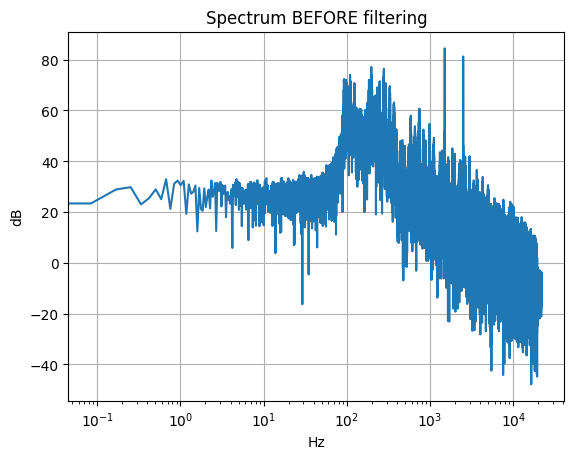

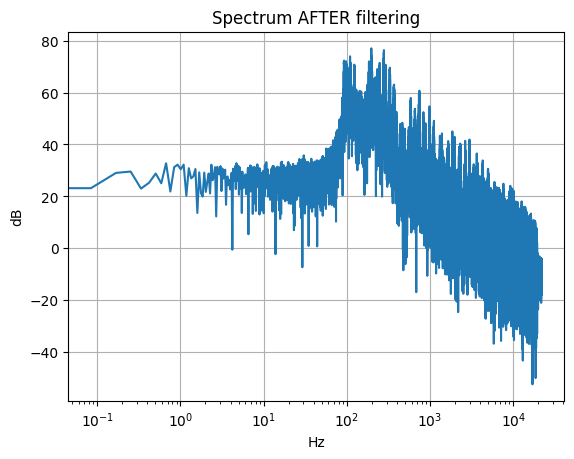

In [2]:
import numpy as np
import soundfile as sf
import scipy.signal as sig
import matplotlib.pyplot as plt
import string

wav_file      = "100-2625-noisy.wav"   
attenuation   = 100                      
step          = 2625                     
bits_per_char = 8                        

noise_peaks_hz: list[float] = []         
Q_notch = 100                            

audio, sr = sf.read(wav_file, dtype="float32", always_2d=True)
frames, chans = audio.shape              

left  = audio[:, 0]
right = audio[:, 1] if chans > 1 else left.copy()
seq   = audio.ravel()                    

print(f"Loaded: {frames} frames  |  {chans} channels  |  {sr} Hz")

N     = 2 ** int(np.ceil(np.log2(seq.size)))
freqs = np.fft.rfftfreq(N, 1/sr)
spec  = np.abs(np.fft.rfft(seq, n=N))

plt.figure("FFT – BEFORE"); plt.clf()
plt.semilogx(freqs, 20*np.log10(spec + 1e-12))
plt.title("Spectrum BEFORE filtering"); plt.xlabel("Hz"); plt.ylabel("dB"); plt.grid(True)

# Auto-detect top noise peaks if not provided
if not noise_peaks_hz:
    mask = freqs > 1000                
    idx  = np.argpartition(spec[mask], -10)[-10:]
    noise_peaks_hz = sorted(freqs[mask][idx])
    print("Auto-detected peaks (Hz):", np.round(noise_peaks_hz, 1))

# Build notch filters for each detected frequency
sos_list = []
for f0 in noise_peaks_hz:
    w0  = f0 / (sr/2)                  
    b, a = sig.iirnotch(w0, Q_notch)   
    sos_list.append(sig.tf2sos(b, a))  

sos_total = np.vstack(sos_list) if sos_list else np.array([[1,0,0,1,0,0]])

seq_filt = sig.sosfiltfilt(sos_total, seq, padtype="odd")

spec_after = np.abs(np.fft.rfft(seq_filt, n=N))
plt.figure("FFT – AFTER"); plt.clf()
plt.semilogx(freqs, 20*np.log10(spec_after + 1e-12))
plt.title("Spectrum AFTER filtering"); plt.xlabel("Hz"); plt.ylabel("dB"); plt.grid(True)

# Estimate message length in characters and bits
total_samples = seq_filt.size
msg_chars     = total_samples // (step * bits_per_char)
msg_bits      = msg_chars * bits_per_char
print(f"\nExpecting {msg_chars} characters ({msg_bits} bits)")

# Convert bit list to text string
def bits_to_text(bits, msb_first=True):
    out = bytearray()
    for i in range(0, len(bits), 8):
        chunk = bits[i:i+8] if msb_first else bits[i:i+8][::-1]
        byte = 0
        for b in chunk:
            byte = (byte << 1) | b
        out.append(byte)
    return out.decode(errors="replace")

# Search best offset and bit order for printable message
best_ratio, best_text = 0.0, ""
for offset in range(step):
    bits = [ (int(round(seq_filt[offset + k*step] * attenuation)) & 1)
             for k in range(msg_bits) ]
    for msb_first in (True, False):
        txt   = bits_to_text(bits, msb_first)
        ratio = sum(c in string.printable for c in txt) / msg_chars
        if ratio > best_ratio:
            best_ratio, best_text = ratio, txt
        if ratio == 1.0:
            break
    if best_ratio == 1.0:
        break

print("\nRecovered hidden message:")
print(best_text)
print("Signals & System\n")